# 03 SHAP analysis and value gap

**Research question 1:** which factors drive market value, in which direction and how strongly? (SHAP)
**Research question 2:** which players are valued well above or below what the data explains? (value gap)

The numbers come from `src/value_gap.py`, which also writes the dashboard exports
(`data/processed/value_gaps.csv`, `data/processed/shap_values.csv`). This notebook explains and visualises them.

**How to read SHAP values here.** The model predicts log(market value). For every player, SHAP splits the
prediction into a starting point (the average prediction, about EUR 9m) plus one contribution per feature.
Because the scale is logarithmic, contributions multiply: an effect of +0.40 means the feature raises this player's
predicted value by exp(0.40) - 1 = +49% compared with an average player. All SHAP results refer to the
**test season 2025/26**, explained with the model trained on 2024/25.

**Value gap** = log(actual value) - log(predicted value). A gap of +0.69 means the market value is twice what the
data explains. Players in the top / bottom 10% of their season are flagged *Above model* / *Below model*.

## 0. Setup

In [1]:
import os
import sys
from pathlib import Path

# joblib counts CPU cores via `wmic`, which Windows 11 no longer ships (noisy warning).
# Setting a limit below the logical core count skips that lookup.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(max(1, (os.cpu_count() or 2) - 1)))

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import shap

from src import config
from src.train_models import load_data
from src.value_gap import FEATURES, compute_gaps, explain

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
POSITION_COLORS = {"Attack": "#2a78d6", "Midfield": "#1baf7a", "Defender": "#eb6a2a"}
GAP_COLORS = {"Above model": "#1c5cab", "In line": "#b5b3ad", "Below model": "#e34948"}
BASE_COLOR = "#2a78d6"
pct_fmt = mtick.FuncFormatter(lambda v, _: f"{v:+.0%}")

def save(fig, name):
    """Save a figure to reports/figures for later use in the README."""
    config.FIGURES.mkdir(parents=True, exist_ok=True)
    fig.savefig(config.FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")

In [2]:
df = load_data()
gaps = compute_gaps(df, pd.read_parquet(config.PREDICTIONS_PATH))
test = gaps[gaps["season"] == config.TEST_SEASON].reset_index(drop=True)

model = joblib.load(config.MODELS_DIR / f"{config.GAP_MODEL}.joblib")
sv = explain(model, test[FEATURES])          # checks that SHAP values add up to the predictions
sv.feature_names = [config.FEATURE_LABELS[f] for f in FEATURES]
shap_df = pd.DataFrame(sv.values, columns=FEATURES)

base = float(np.ravel(sv.base_values)[0])
print(f"Test season {config.season_label(config.TEST_SEASON)}: {len(test):,} players")
print(f"Average prediction (SHAP base value): log {base:.2f} = EUR {np.exp(base) / 1e6:.1f}m")

Test season 2025/26: 1,482 players
Average prediction (SHAP base value): log 16.02 = EUR 9.1m


## 1. Which features matter most? (global importance)
Mean absolute SHAP value per feature: how much a feature moves the prediction on average, regardless of direction.
Shown as a share of the total, comparable to the gain importance in notebook 02 but measured on the test season.

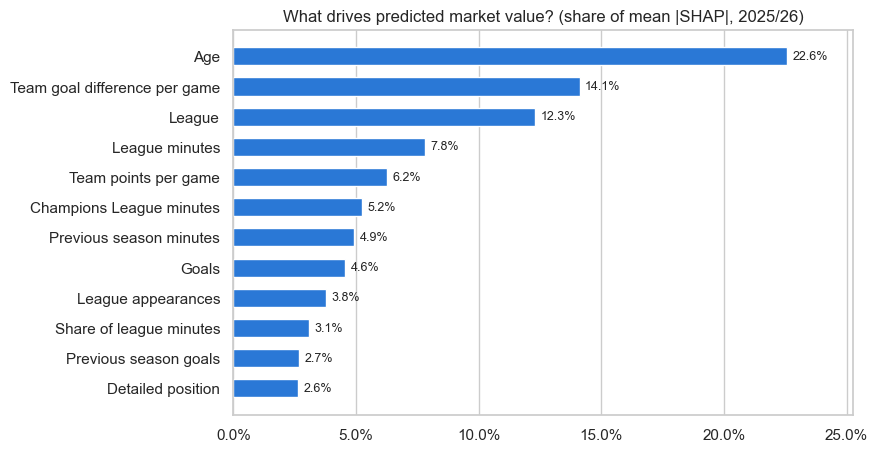

In [3]:
mean_abs = shap_df.abs().mean().rename(index=config.FEATURE_LABELS)
share = (mean_abs / mean_abs.sum()).sort_values().tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(share.index, share.values, color=BASE_COLOR, height=0.6)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in share.values], padding=4, fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.grid(axis="y", visible=False)
ax.margins(x=0.12)
ax.set(title=f"What drives predicted market value? (share of mean |SHAP|, {config.season_label(config.TEST_SEASON)})")
save(fig, "09_shap_importance")
plt.show()

## 2. Direction of the effects (beeswarm)
Each dot is one player. Position on the x-axis = effect on the predicted value (right = higher), colour = the
feature's value for that player (red = high, blue = low). Example: for *Age*, red dots (old players) sit on the left,
so higher age lowers the value. Categorical features (league, position) appear grey because they have no
"high" or "low".

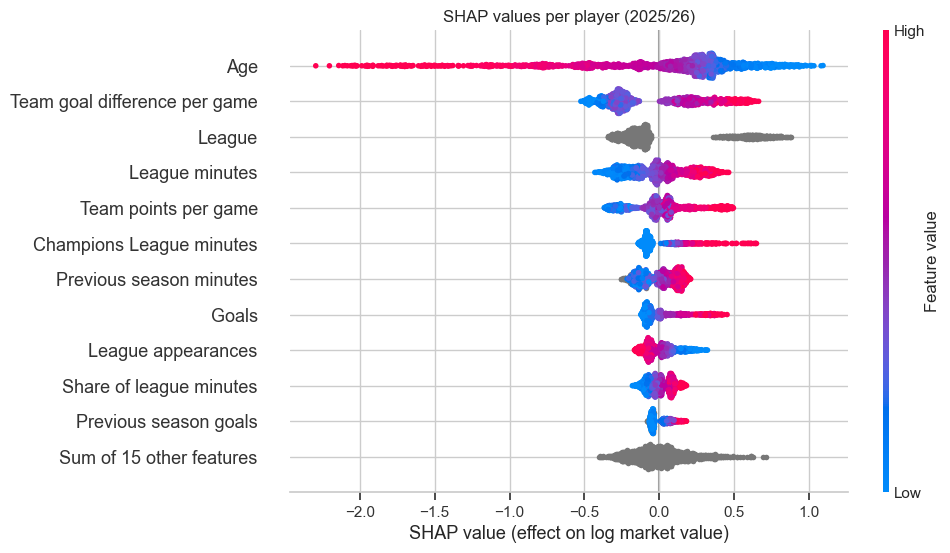

In [4]:
shap.plots.beeswarm(sv, max_display=12, show=False, plot_size=(9, 6))
fig = plt.gcf()
fig.axes[0].set_title(f"SHAP values per player ({config.season_label(config.TEST_SEASON)})")
fig.axes[0].set_xlabel("SHAP value (effect on log market value)")
save(fig, "10_shap_beeswarm")
plt.show()

## 3. How each driver works (dependence plots)
Feature value on the x-axis, its SHAP effect in % on the y-axis, coloured by position. The bottom-right panel answers
the question from notebook 02: **is a goal worth more for some positions than for others?**

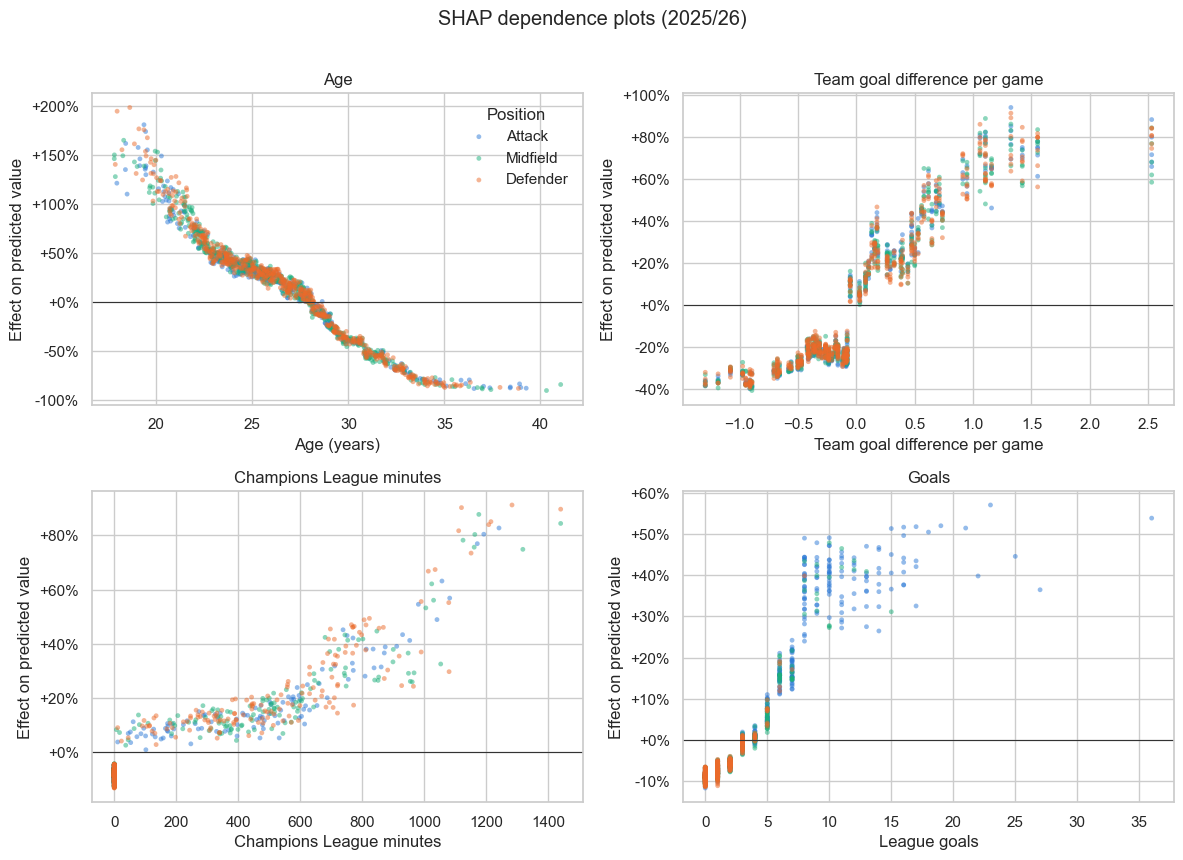

In [5]:
panels = [("age", "Age (years)"), ("team_goal_diff_pg", "Team goal difference per game"),
          ("cl_minutes", "Champions League minutes"), ("goals", "League goals")]

fig, axes = plt.subplots(2, 2, figsize=(12, 8.5), sharey=False)
for ax, (feat, xlabel) in zip(axes.ravel(), panels):
    effect = np.exp(shap_df[feat]) - 1
    for pos, color in POSITION_COLORS.items():
        m = test["position"] == pos
        ax.scatter(test.loc[m, feat], effect[m], s=12, alpha=0.5, color=color, label=pos, edgecolors="none")
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.set(xlabel=xlabel, ylabel="Effect on predicted value", title=config.FEATURE_LABELS[feat])
axes[0, 0].legend(title="Position", frameon=False)
fig.suptitle(f"SHAP dependence plots ({config.season_label(config.TEST_SEASON)})", y=1.01)
fig.tight_layout()
save(fig, "11_shap_dependence")
plt.show()

A goal also raises goals per 90 and goal contributions per 90, and the model splits the credit between these
correlated features. The table therefore shows two slopes per position: the `goals` feature alone (the panel above)
and the sum of all three goal-related features, which is the full effect of one more goal.

In [6]:
# Average effect of one additional goal per position (slope of SHAP effect vs goals)
GOAL_FEATURES = ["goals", "goals_p90", "goal_contrib_p90"]
rows = []
for pos in POSITION_COLORS:
    m = test["position"] == pos
    only = np.polyfit(test.loc[m, "goals"], shap_df.loc[m, "goals"], 1)[0]
    total = np.polyfit(test.loc[m, "goals"], shap_df.loc[m, GOAL_FEATURES].sum(axis=1), 1)[0]
    rows.append({"position": pos, "players": int(m.sum()), "median_goals": test.loc[m, "goals"].median(),
                 "goals feature only": np.exp(only) - 1, "all goal features": np.exp(total) - 1})
(pd.DataFrame(rows).set_index("position")
   .style.format({"goals feature only": "{:+.1%}", "all goal features": "{:+.1%}", "median_goals": "{:.0f}"}))

,players,median_goals,goals feature only,all goal features
position,,,,
Attack,407,5,+3.0%,+4.0%
Midfield,474,2,+3.9%,+5.7%
Defender,601,1,+3.0%,+5.2%


## 4. Value gap: distribution
Dashed lines mark the 10% and 90% quantiles of each season: everything outside is flagged. In 2025/26 the whole
distribution is shifted to the right: the model trained on 2024/25 under-predicts the typical player by about 15%.
Roughly half of that is a higher value level, the other half lower predictions caused by a shift in team strength
within the sample (see notebook 04, section 3). Flagging by quantile *within* each season removes that shift.

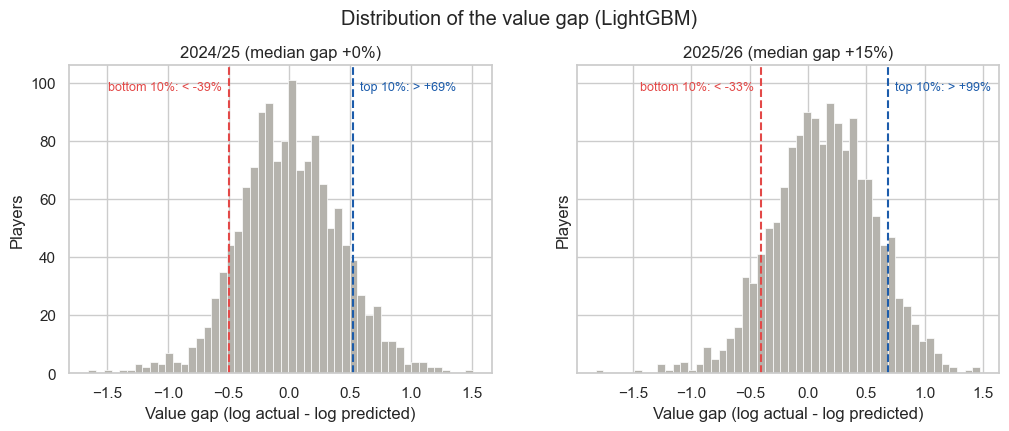

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (label, g) in zip(axes, gaps.groupby("season_label")):
    lo, med, hi = g["gap_log"].quantile([config.GAP_QUANTILE, 0.5, 1 - config.GAP_QUANTILE])
    ax.hist(g["gap_log"], bins=50, color=GAP_COLORS["In line"], edgecolor="white", linewidth=0.5)
    for x, cat in [(lo, "Below model"), (hi, "Above model")]:
        ax.axvline(x, color=GAP_COLORS[cat], linestyle="--", linewidth=1.5)
    ax.text(hi, ax.get_ylim()[1] * 0.92, f"  top 10%: > {np.exp(hi) - 1:+.0%}", color=GAP_COLORS["Above model"], fontsize=9)
    ax.text(lo, ax.get_ylim()[1] * 0.92, f"bottom 10%: < {np.exp(lo) - 1:+.0%}  ", color=GAP_COLORS["Below model"],
            fontsize=9, ha="right")
    med_pct = round(np.exp(med) - 1, 2) + 0.0   # + 0.0 turns -0.0 into 0.0
    ax.set(title=f"{label} (median gap {med_pct:+.0%})", xlabel="Value gap (log actual - log predicted)",
           ylabel="Players")
fig.suptitle("Distribution of the value gap (LightGBM)", y=1.02)
save(fig, "12_gap_distribution")
plt.show()

## 5. Who is valued above / below the model? (2025/26)
`models_agree` = Ridge puts the player in the same category. Cases where both models agree are the more robust ones.
`driver_up_1` / `driver_down_1` = the feature that raises / lowers this player's predicted value most.

In [8]:
drivers = pd.read_csv(config.VALUE_GAPS_PATH, encoding="utf-8-sig")[
    ["player_id", "season", "driver_up_1", "driver_down_1"]]
show = test.merge(drivers, on=["player_id", "season"], how="left").assign(
    value_m=lambda d: d["market_value"] / 1e6, predicted_m=lambda d: d["predicted_value"] / 1e6)
cols = ["name", "club_name", "position", "age", "minutes", "value_m", "predicted_m", "gap_pct", "models_agree",
        "driver_up_1", "driver_down_1"]
fmt = {"age": "{:.0f}", "minutes": "{:,.0f}", "value_m": "{:.1f}", "predicted_m": "{:.1f}", "gap_pct": "{:+.0%}"}

print("Top 10 above model (market value higher than the data explains)")
display(show.nlargest(10, "gap_log")[cols].style.format(fmt).hide(axis="index"))

Top 10 above model (market value higher than the data explains)


name,club_name,position,age,minutes,value_m,predicted_m,gap_pct,models_agree,driver_up_1,driver_down_1
Jérémy Jacquet,Stade Rennais FC,Defender,20,"1,673",55.0,12.6,+337%,True,Age (+113%),League (-22%)
Tylel Tati,FC Nantes,Defender,18,"1,724",25.0,6.0,+313%,True,Age (+194%),Team goal difference per game (-30%)
Aymeric Laporte,Athletic Bilbao,Defender,32,"2,060",8.0,2.1,+290%,True,Champions League minutes (+13%),Age (-54%)
Elye Wahi,OGC Nice,Attack,23,"1,249",18.0,5.0,+257%,True,Age (+39%),Team goal difference per game (-34%)
Marshall Munetsi,Paris FC,Midfield,30,"1,852",15.0,4.4,+242%,True,Previous season minutes (+16%),Age (-35%)
Jack Grealish,Everton FC,Attack,30,"1,632",20.0,6.0,+232%,False,League (+91%),Age (-42%)
Lovro Majer,VfL Wolfsburg,Midfield,28,"1,375",8.0,2.4,+230%,True,Goals + assists per 90 (+5%),Team goal difference per game (-34%)
Jeff Ekhator,Genoa CFC,Attack,19,944,18.0,5.7,+217%,True,Age (+146%),League minutes (-32%)
Chrislain Matsima,FC Augsburg,Defender,24,"1,490",22.0,7.3,+203%,True,Age (+46%),Team goal difference per game (-27%)
Nathaniel Brown,Eintracht Frankfurt,Defender,23,"2,658",40.0,13.3,+200%,False,Age (+64%),Team goal difference per game (-29%)


In [9]:
print("Top 10 below model (market value lower than the data explains)")
display(show.nsmallest(10, "gap_log")[cols].style.format(fmt).hide(axis="index"))

Top 10 below model (market value lower than the data explains)


name,club_name,position,age,minutes,value_m,predicted_m,gap_pct,models_agree,driver_up_1,driver_down_1
Adam Smith,AFC Bournemouth,Defender,35,"1,080",0.3,1.9,-84%,True,League (+84%),Age (-83%)
Domingos Duarte,Getafe CF,Defender,31,"2,929",0.8,3.4,-76%,True,League minutes (+31%),Age (-51%)
Idrissa Gueye,Everton FC,Midfield,36,"2,102",0.5,1.8,-72%,True,League (+75%),Age (-86%)
Youssef El Arabi,FC Nantes,Attack,39,938,0.1,0.3,-71%,True,Goals + assists per 90 (+8%),Age (-83%)
Nicolas Pépé,Villarreal CF,Attack,31,"2,397",6.0,20.8,-71%,True,Team goal difference per game (+54%),Age (-41%)
Lautaro Valenti,Parma Calcio 1913,Defender,27,"2,251",2.0,6.7,-70%,True,Age (+13%),Team goal difference per game (-27%)
Ramy Bensebaini,Borussia Dortmund,Defender,31,"1,528",7.0,22.1,-68%,True,Team goal difference per game (+80%),Age (-39%)
Ignace Van der Brempt,Como 1907,Defender,24,931,3.0,9.3,-68%,True,Team goal difference per game (+65%),League minutes (-27%)
Adrián Liso,Getafe CF,Attack,21,"1,712",3.0,9.0,-67%,True,Age (+117%),Team goal difference per game (-23%)
Emanuele Valeri,Parma Calcio 1913,Defender,27,"2,646",3.0,8.8,-66%,True,League minutes (+31%),Team goal difference per game (-26%)


## 6. Is the gap systematic? (by age group and league)
Uses the season-centred gap, so the season-level shift in 2025/26 does not distort the comparison. If the model
captured everything, every group would sit around 0% with about 10% of players in each tail.

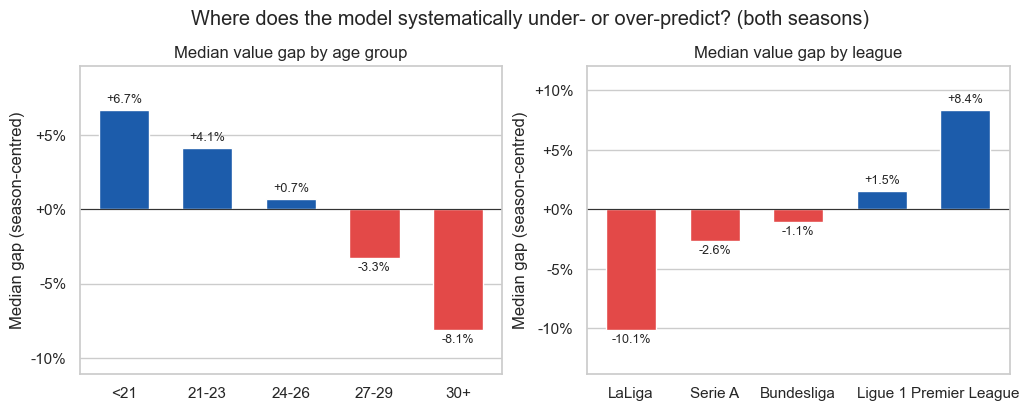

gap_category,Above model,Below model
age_group,,
<21,14.8%,6.4%
21-23,11.8%,9.2%
24-26,9.0%,9.0%
27-29,8.7%,9.9%
30+,9.5%,13.8%


In [10]:
gaps["age_group"] = pd.cut(gaps["age"], bins=config.AGE_BINS, labels=config.AGE_LABELS, right=False)
gaps["league_name"] = gaps["league"].astype(str).map(config.TOP5_LEAGUES)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [(axes[0], "age_group", "by age group"), (axes[1], "league_name", "by league")]:
    med = gaps.groupby(col, observed=True)["gap_pct_centred"].median()
    if col == "league_name":
        med = med.sort_values()
    colors = [GAP_COLORS["Above model"] if v > 0 else GAP_COLORS["Below model"] for v in med.values]
    bars = ax.bar(med.index.astype(str), med.values, color=colors, width=0.6)
    ax.bar_label(bars, labels=[f"{v:+.1%}" for v in med.values], padding=3, fontsize=9)
    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.yaxis.set_major_locator(mtick.MultipleLocator(0.05))
    ax.yaxis.set_major_formatter(pct_fmt)
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.2)
    ax.set(title=f"Median value gap {title}", ylabel="Median gap (season-centred)")
fig.suptitle("Where does the model systematically under- or over-predict? (both seasons)", y=1.02)
save(fig, "13_gap_by_group")
plt.show()

(gaps.groupby("age_group", observed=True)["gap_category"].value_counts(normalize=True)
     .unstack()[["Above model", "Below model"]].style.format("{:.1%}"))

## 7. Do gaps persist from one season to the next?
For players in the sample in both seasons. If gaps were pure noise, the correlation would be about 0 and a flagged
player would land in the same category again only 10% of the time.

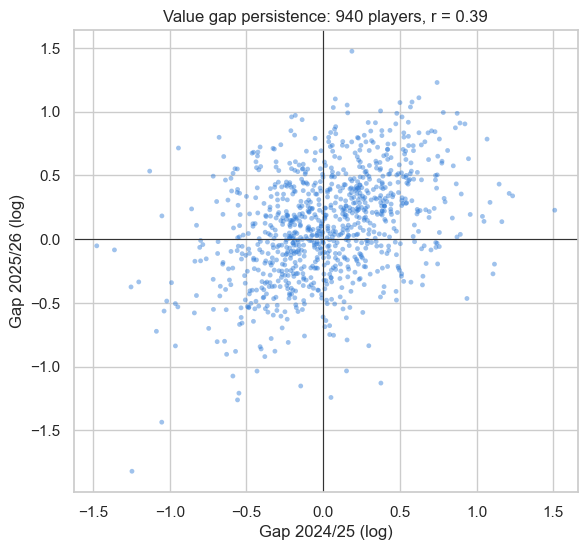

gap_category_2025_26,Above model,Below model,In line
gap_category_2024_25,,,
Above model,26%,1%,73%
Below model,2%,31%,67%
In line,7%,10%,82%


In [11]:
both = gaps.dropna(subset=["gap_log_prev_season"])
r = both[["gap_log", "gap_log_prev_season"]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(both["gap_log_prev_season"], both["gap_log"], s=12, alpha=0.45, color=BASE_COLOR, edgecolors="none")
ax.axhline(0, color="#333333", linewidth=0.8)
ax.axvline(0, color="#333333", linewidth=0.8)
ax.set(xlabel=f"Gap {config.season_label(config.TRAIN_SEASON)} (log)", ylabel=f"Gap {config.season_label(config.TEST_SEASON)} (log)",
       title=f"Value gap persistence: {len(both):,} players, r = {r:.2f}")
save(fig, "14_gap_persistence")
plt.show()

prev_cat = gaps[gaps["season"] == config.TRAIN_SEASON][["player_id", "gap_category"]]
curr_cat = gaps[gaps["season"] == config.TEST_SEASON][["player_id", "gap_category"]]
moves = prev_cat.merge(curr_cat, on="player_id", suffixes=("_2024_25", "_2025_26"))
pd.crosstab(moves["gap_category_2024_25"], moves["gap_category_2025_26"], normalize="index").style.format("{:.0%}")

## 8. Explaining single players (waterfall)
Starts at the average prediction (bottom, E[f(X)]) and adds each feature's contribution until it reaches this
player's prediction f(x) at the top. Values are in log units; the actual market value is given in the title.

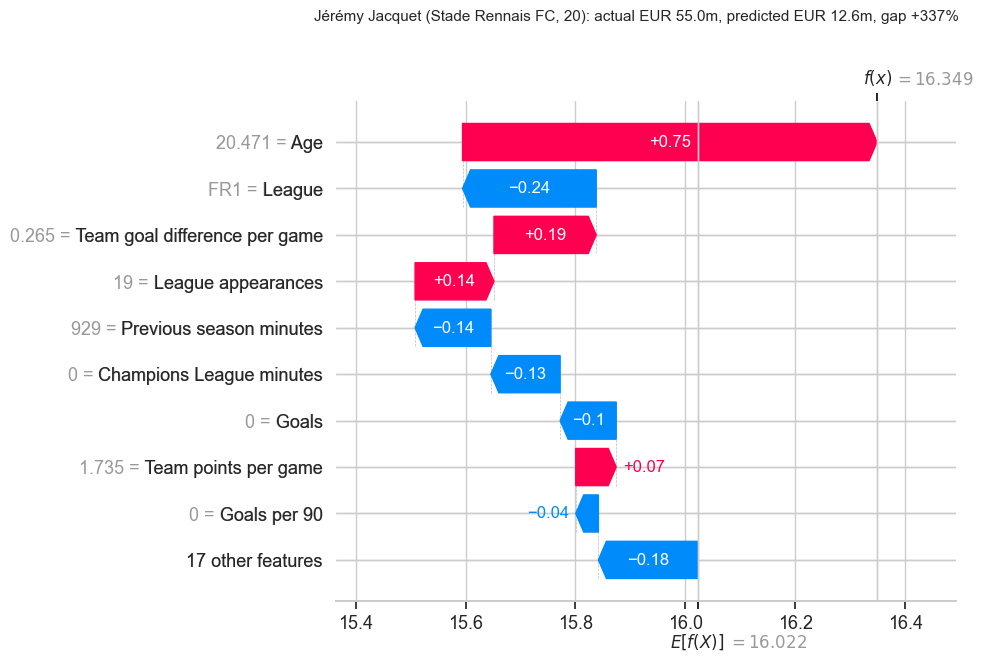

In [12]:
def waterfall(name):
    i = test.index[test["name"] == name][0]
    row = test.loc[i]
    shap.plots.waterfall(sv[i], max_display=10, show=False)
    fig = plt.gcf()
    fig.suptitle(f"{name} ({row['club_name']}, {row['age']:.0f}): actual EUR {row['market_value'] / 1e6:.1f}m, "
                 f"predicted EUR {row['predicted_value'] / 1e6:.1f}m, gap {row['gap_pct']:+.0%}", y=1.02, fontsize=11)
    return fig

top_above = test.loc[test["gap_log"].idxmax(), "name"]
save(waterfall(top_above), "15_waterfall_above")
plt.show()

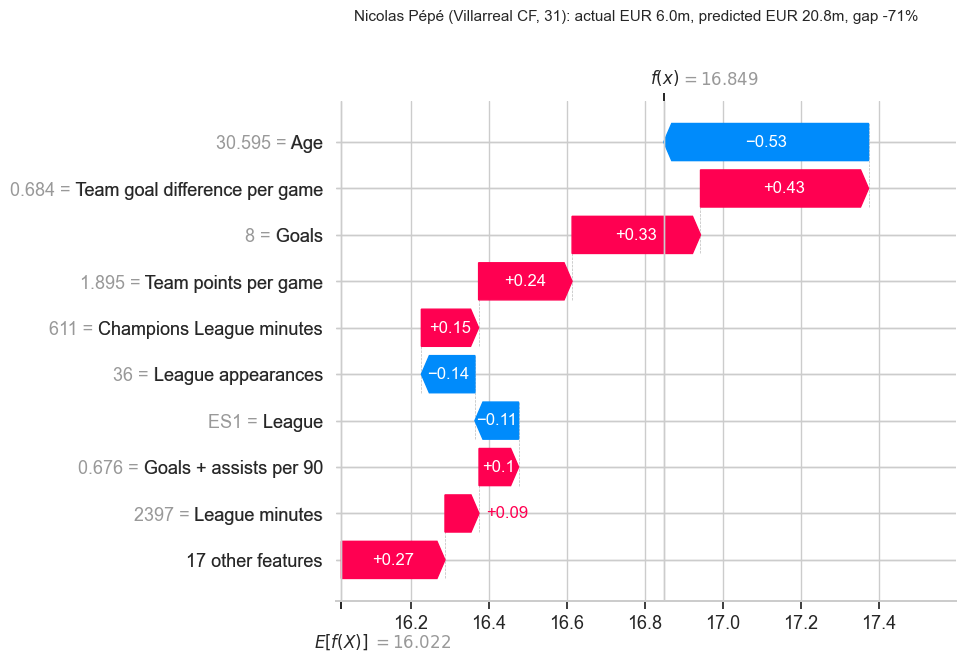

In [13]:
example_below = "Nicolas Pépé"   # mid-career player at a strong team, valued far below the model
save(waterfall(example_below), "16_waterfall_below")
plt.show()

## 9. Findings
*Numbers from the run on 2026-10-01; reproduced by `python -m src.value_gap`.*

**Drivers (research question 1)**
- **Age is the strongest driver** (23% of mean |SHAP|), followed by **team strength** (goal difference 14%, points
  per game 6%) and **league** (12%). Playing time (league minutes 8%, previous season minutes 5%) and Champions
  League minutes (5%) matter more than output: goals account for only 5%.
- **A goal is not worth more for attackers:** counting all goal-related features, one more goal adds about +4% for
  attackers, +5% for defenders and +6% for midfielders. Attackers are more valuable because they score more, not
  because a goal counts more for them (consistent with the position analysis in notebook 02).

**Value gap (research question 2)**
- The 10% tails start at about **+70% to +100%** above and **-33% to -39%** below the prediction. A fixed +/-50%
  threshold would have flagged 31-37% of all players.
- **Above model** is dominated by young talents at mid-table clubs (e.g. Jacquet, Tati) and established names
  (Laporte, Grealish): potential and reputation are not in the data. **Below model** is dominated by players over
  30, whom the market values lower than their age, team and output would suggest.
- **The gap is partly systematic:** under-21s land in the top 10% in 15% of cases, over-30s in the bottom 10% in
  14%. By league, LaLiga players sit about 10% below the model and Premier League players about 8% above it.
- **Gaps persist:** r = 0.39 between seasons. 26% of players above the model in 2024/25 are above it again in
  2025/26, and 31% of those below stay below (vs 10% if gaps were random). Only 1-2% switch sides.
- **Robustness:** Ridge agrees with LightGBM on the category for 55-57% of flagged players. The `models_agree` column
  marks the more robust cases for the scouting list.

**Interpretation.** A gap is not mispricing by itself: it shows where the market prices something the data does not
contain (potential, reputation, injuries, playing style). Persistent gaps point to such stable, unobserved factors.

**Next step (day 5):** Power BI dashboard on top of `value_gaps.csv` and `shap_values.csv`.